# Review 6. SN 2011fe at several phases

How far a spectrum moves with phase near maximum light, shown on the SN 2011fe
time series.

| input | what it provides |
| --- | --- |
| `spec_2011fe/2011fe_<phase>.{dat,ascii}` | the spectra; the file name ends in the phase (`m20` -> -2.0 d, `02` -> +0.2 d) |

| output | what it shows |
| --- | --- |
| `figure/review/2011fe.pdf` / `.png` | the rest-frame, median-normalized spectra, coloured by phase |


## Imports


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## Configuration


In [2]:
# Input / output locations
SPEC_2011FE_DIR = './spec_2011fe'
SPEC_2011FE_GLOB = '2011fe_*'

FIGURE_DIR = './figure/review'
OUTPUT_NAME = '2011fe'

os.makedirs(FIGURE_DIR, exist_ok=True)

# SN 2011fe and the range drawn
REDSHIFT = 0.000804
WAVE_MIN_AA, WAVE_MAX_AA = 5000, 7000
PHASE_VMIN, PHASE_VMAX = -2.5, 2.5


In [3]:
plt.rcParams['figure.figsize'] = (10.0, 5.0)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Arial'

plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['xtick.bottom'] = 'True'
plt.rcParams['xtick.top'] = 'True'
plt.rcParams['ytick.left'] = 'True'
plt.rcParams['ytick.right'] = 'True'
plt.rcParams["xtick.minor.visible"] = 'True'
plt.rcParams["ytick.minor.visible"] = 'True'

plt.rcParams["xtick.major.width"] = 1
plt.rcParams["ytick.major.width"] = 1
plt.rcParams["xtick.minor.width"] = 0.5
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["xtick.major.size"] = 7
plt.rcParams["ytick.major.size"] = 7
plt.rcParams["xtick.minor.size"] = 4
plt.rcParams["ytick.minor.size"] = 4

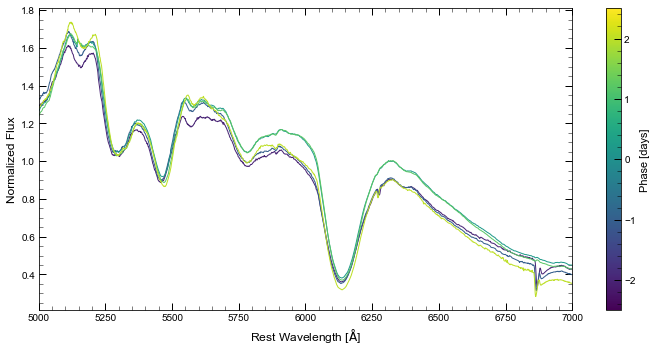

In [4]:
import glob

z = REDSHIFT
wave_min, wave_max = WAVE_MIN_AA, WAVE_MAX_AA
phase_vmin, phase_vmax = PHASE_VMIN, PHASE_VMAX

def parse_phase(path):
    """Phase from the file name: m20 -> -2.0, 02 -> +0.2."""
    tag = os.path.splitext(os.path.basename(path))[0].split('_')[-1]
    return -float(tag[1:]) / 10 if tag.startswith('m') else float(tag) / 10

files = sorted(glob.glob(os.path.join(SPEC_2011FE_DIR, SPEC_2011FE_GLOB)), key=parse_phase)

fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=phase_vmin, vmax=phase_vmax)

for path in files:
    phase = parse_phase(path)
    wave, flux = np.loadtxt(path, comments='#', usecols=(0, 1), unpack=True)
    wave = wave / (1 + z)                                   # to the rest frame
    mask = (wave >= wave_min) & (wave <= wave_max)
    wave, flux = wave[mask], flux[mask]
    ax.plot(wave, flux / np.median(flux), color=cmap(norm(phase)), lw=1.0,
            label=f'{phase:+.1f} d')

cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)
cbar.set_label('Phase [days]', fontsize=11)

ax.set_xlabel(r'Rest Wavelength [$\rm \AA$]', fontsize=12)
ax.set_ylabel('Normalized Flux', fontsize=12)
ax.set_xlim(wave_min, wave_max)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/{OUTPUT_NAME}.pdf', bbox_inches='tight', pad_inches=0.05)
fig.savefig(f'{FIGURE_DIR}/{OUTPUT_NAME}.png', bbox_inches='tight', pad_inches=0.05)
plt.show()
